In [1]:
# Let's add the root directory to our system search path to allow imports from sibling directories.
import os, sys
module_path = os.path.abspath(os.path.join(".."))
if module_path not in sys.path:
    sys.path.append(module_path)

In [ ]:
import random
from pathlib import Path

import cv2
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF

from tqdm.notebook import tqdm

from src.utils import load_backbone, run_inference, show_images, generate_evaluation_report

WEIGHTS_DIR = Path("../weights/")
EPOCH_COUNT = len(list(WEIGHTS_DIR.iterdir())) - 2

DEVICE = torch.device("cuda")  # ConvNeXtV2 doesn't support CPU

SEED = 42
RNG = np.random.default_rng(seed=SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DATASET_PATH = Path("../data/labelled/AI4Shipwrecks")
IMGS_PATH = DATASET_PATH / "images/"
MASK_PATH = DATASET_PATH / "masks/"
EMBEDS_PATH = DATASET_PATH / "embeds/"
DATA_EXT = '.png'

# Few Shot Scalability (1%, 5%, 10%, 50%, 100%)
FEW_SHOT = (0.01, 0.05, 0.10, 0.50, 1.00)

TRAIN_SURVEYS = {'DM_Wilson', 'DR_Hanna', 'EB_Allen', 'Egyptian', 'Grecian', 'Heart_Failure', 'Isaac_M_Scott', 'Montana', 'Oscar_T_Flint', 'Pewabic', 'WP_Rend'}

DATA_FILES = [im.stem for im in IMGS_PATH.glob(f"*{DATA_EXT}")]
N = len(DATA_FILES)

TRAIN_FILES = [f for f in DATA_FILES if '_'.join(f.split('_')[0:-3]) in TRAIN_SURVEYS]
TEST_FILES = [f for f in DATA_FILES if '_'.join(f.split('_')[0:-3]) not in TRAIN_SURVEYS]

MODEL_PATH = WEIGHTS_DIR / "unet_shipwreck_final.pth"

In [3]:
class DoubleConv(nn.Module):
    """
    Standard U-Net Double Convolution Block:
    (Conv2d -> BatchNorm2d -> ReLU) * 2
    """
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNetShipwreckDecoder(nn.Module):
    def __init__(self):
        super(UNetShipwreckDecoder, self).__init__()

        # --- Stage: W/32 to W/16 ---
        self.up_w32 = nn.ConvTranspose2d(768, 384, kernel_size=4, stride=2, padding=1)
        # Concat: 384 (upsampled) + 384 (skip) = 768 -> DoubleConv reduces to 384
        self.conv_w16 = DoubleConv(768, 384)

        # --- Stage: W/16 to W/8 ---
        self.up_w16 = nn.ConvTranspose2d(384, 192, kernel_size=4, stride=2, padding=1)
        # Concat: 192 (upsampled) + 192 (skip) = 384 -> DoubleConv reduces to 192
        self.conv_w8 = DoubleConv(384, 192)

        # --- Stage: W/8 to W/4 ---
        self.up_w8 = nn.ConvTranspose2d(192, 96, kernel_size=4, stride=2, padding=1)
        # Concat: 96 (upsampled) + 96 (skip) = 192 -> DoubleConv reduces to 96
        self.conv_w4 = DoubleConv(192, 96)

        # --- Stage: W/4 to W/2 (No skip connection available from backbone here) ---
        self.up_w4 = nn.ConvTranspose2d(96, 64, kernel_size=4, stride=2, padding=1)
        self.conv_w2 = DoubleConv(64, 64)

        # --- Stage: W/2 to Final Native Resolution (No skip connection) ---
        self.up_w2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.conv_final = DoubleConv(32, 32)

        # Final 1x1 convolution to map to binary mask (1 channel)
        self.classifier = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, s_w32, s_w16, s_w8, s_w4):
        """
        Expects inputs in order from lowest spatial resolution to highest:
        s_w32: 768c
        s_w16: 384c
        s_w8:  192c
        s_w4:  96c
        """
        # 1. Upsample W/32, match size, concat with W/16
        x = self.up_w32(s_w32)
        x = torch.cat([x, s_w16], dim=1)
        x = self.conv_w16(x)

        # 2. Upsample W/16, match size, concat with W/8
        x = self.up_w16(x)
        x = torch.cat([x, s_w8], dim=1)
        x = self.conv_w8(x)

        # 3. Upsample W/8, match size, concat with W/4
        x = self.up_w8(x)
        x = torch.cat([x, s_w4], dim=1)
        x = self.conv_w4(x)

        # 4. Upsample to W/2 and apply features
        x = self.up_w4(x)
        x = self.conv_w2(x)

        # 5. Upsample to native image size (W) and apply features
        x = self.up_w2(x)
        x = self.conv_final(x)

        # 6. Final classification
        logits = self.classifier(x)

        return logits.squeeze(1)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        """
        Args:
            alpha (float): Weighting factor for the positive class (shipwrecks).
            gamma (float): Focusing parameter. Higher values reduce the loss for well-classified examples.
            reduction (str): 'mean', 'sum', or 'none'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Calculate standard BCE with logits (no reduction so we can apply the focal weights per-pixel)
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Get the predicted probabilities
        probs = torch.sigmoid(inputs)

        # p_t is the probability of the true class
        p_t = probs * targets + (1 - probs) * (1 - targets)

        # Calculate the modulating factor (1 - p_t)^gamma
        modulating_factor = (1.0 - p_t) ** self.gamma

        # Calculate the alpha weighting factor
        alpha_factor = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)

        # Combine everything
        focal_loss = alpha_factor * modulating_factor * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, smooth=1.0):
        super(FocalDiceLoss, self).__init__()
        # Initialize your existing Focal Loss with a moderate alpha
        self.focal = FocalLoss(alpha=alpha, gamma=gamma, reduction='mean')
        self.smooth = smooth

    def forward(self, inputs, targets):
        # 1. Calculate Focal Loss
        focal_loss = self.focal(inputs, targets)
        
        # 2. Calculate Dice Loss
        probs = torch.sigmoid(inputs)
        
        # Flatten tensors to 1D to calculate global intersection
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        
        intersection = (probs_flat * targets_flat).sum()
        
        # Dice coefficient formula: (2 * Intersection) / (Prediction_Sum + Target_Sum)
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score
        
        # Combine both losses
        return focal_loss + dice_loss


class DynamicShipwreckDataset(Dataset):
    def __init__(self, file_list, mask_dir, embeds_dir, data_ext='.png', augment=False):
        self.file_list = file_list
        self.mask_dir = Path(mask_dir)
        self.embeds_dir = Path(embeds_dir)
        self.data_ext = data_ext
        self.augment = augment

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_id = self.file_list[idx]
        survey_name = '_'.join(file_id.split('_')[0:-3])

        mask_path = self.mask_dir / (file_id + self.data_ext)
        embed_path = self.embeds_dir / (file_id + '.npz')

        # Read mask on demand: (H, W)
        mask_np = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
        mask = torch.from_numpy(mask_np)

        # Load embeddings on demand
        with np.load(embed_path) as data:
            # Map stages: stage3 (W/32), stage2 (W/16), stage1 (W/8), stage0 (W/4)
            # Permute from (H, W, C) -> (C, H, W)
            s1 = torch.from_numpy(data['stage3'].astype(np.float32)).permute(2, 0, 1)
            s2 = torch.from_numpy(data['stage2'].astype(np.float32)).permute(2, 0, 1)
            s3 = torch.from_numpy(data['stage1'].astype(np.float32)).permute(2, 0, 1)
            s4 = torch.from_numpy(data['stage0'].astype(np.float32)).permute(2, 0, 1)

        # Synchronized Data Augmentation (Train only)
        if self.augment:
            if random.random() > 0.5:
                s1 = TF.hflip(s1)
                s2 = TF.hflip(s2)
                s3 = TF.hflip(s3)
                s4 = TF.hflip(s4)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                s1 = TF.vflip(s1)
                s2 = TF.vflip(s2)
                s3 = TF.vflip(s3)
                s4 = TF.vflip(s4)
                mask = TF.vflip(mask)

        return survey_name, (s1, s2, s3, s4), mask

In [4]:
EMBEDS_PATH.mkdir(exist_ok=True)

embed_files = list(EMBEDS_PATH.glob('*.npz'))
if len(embed_files) < N:
    model = load_backbone(WEIGHTS_DIR / "checkpoint_latest.pth")

    for file in tqdm(DATA_FILES):
        embed_path = EMBEDS_PATH / (file + '.npz')
        if embed_path.exists():
            continue

        img_path = IMGS_PATH / (file + DATA_EXT)
        img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        img = torch.from_numpy(img[np.newaxis, :, :])  # (W, H) -> (1, W, H)

        cls, flat_patches, outputs = run_inference(model, img)
        np.savez_compressed(
            embed_path,
            cls=cls,
            stage0=outputs[0],
            stage1=outputs[1],
            stage2=outputs[2],
            stage3=outputs[3],
            stage4=outputs[4],  # Fused Hypercolumn
        )

In [5]:
train_dataset = DynamicShipwreckDataset(
    file_list=TRAIN_FILES,
    mask_dir=MASK_PATH,
    embeds_dir=EMBEDS_PATH,
    data_ext=DATA_EXT,
    augment=True
)

test_dataset = DynamicShipwreckDataset(
    file_list=TEST_FILES,
    mask_dir=MASK_PATH,
    embeds_dir=EMBEDS_PATH,
    data_ext=DATA_EXT,
    augment=False
)

BATCH_SIZE = 8
# num_workers=4 and pin_memory=True allow background loading while GPU computes
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [6]:
# Label guide: Class 0 -> Background, Class 1 -> Shipwreck
model = UNetShipwreckDecoder().to(DEVICE)
criterion = FocalDiceLoss(alpha=0.99, gamma=3.0).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

EPOCHS = 100

print(f"Training on {DEVICE}...")

prev_loss = np.inf
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for s_name, stages, batch_masks in train_loader:
        s1_b, s2_b, s3_b, s4_b = [s.to(DEVICE, non_blocking=True) for s in stages]
        batch_masks = batch_masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(s1_b, s2_b, s3_b, s4_b)
        loss = criterion(logits, batch_masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_epoch_loss:.4f}")
    scheduler.step(avg_epoch_loss)

    if avg_epoch_loss <= prev_loss:
        torch.save(model.state_dict(), MODEL_PATH)
        prev_loss = avg_epoch_loss

print("\nTraining Complete.")

Training on cuda...


/home/hayat/projects/benthic/venv/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/100] | Train Loss: 0.6232
Epoch [2/100] | Train Loss: 0.4914
Epoch [3/100] | Train Loss: 0.4528
Epoch [4/100] | Train Loss: 0.4320
Epoch [5/100] | Train Loss: 0.3843
Epoch [6/100] | Train Loss: 0.3662
Epoch [7/100] | Train Loss: 0.3571
Epoch [8/100] | Train Loss: 0.3384
Epoch [9/100] | Train Loss: 0.3276
Epoch [10/100] | Train Loss: 0.3089
Epoch [11/100] | Train Loss: 0.2950
Epoch [12/100] | Train Loss: 0.2896
Epoch [13/100] | Train Loss: 0.2870
Epoch [14/100] | Train Loss: 0.2916
Epoch [15/100] | Train Loss: 0.2721
Epoch [16/100] | Train Loss: 0.2722
Epoch [17/100] | Train Loss: 0.2674
Epoch [18/100] | Train Loss: 0.2546
Epoch [19/100] | Train Loss: 0.2641
Epoch [20/100] | Train Loss: 0.2479
Epoch [21/100] | Train Loss: 0.2458
Epoch [22/100] | Train Loss: 0.2487
Epoch [23/100] | Train Loss: 0.2276
Epoch [24/100] | Train Loss: 0.2377
Epoch [25/100] | Train Loss: 0.2205
Epoch [26/100] | Train Loss: 0.2388
Epoch [27/100] | Train Loss: 0.2170
Epoch [28/100] | Train Loss: 0.2136
E

In [6]:
loaded_model = UNetShipwreckDecoder().to(DEVICE)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

all_preds = []
all_targets = []

survey_pred = {}
survey_targets = {}

with torch.no_grad():
    for s_names, stages, batch_masks in test_loader:
        s1_b, s2_b, s3_b, s4_b = [s.to(DEVICE, non_blocking=True) for s in stages]
        logits = loaded_model(s1_b, s2_b, s3_b, s4_b)

        probs = torch.sigmoid(logits)

        all_preds.append(probs.cpu().numpy().flatten())
        all_targets.append(batch_masks.numpy().flatten())

        for i, s_name in enumerate(s_names):
            if s_name not in survey_pred:
                survey_pred[s_name] = []
                survey_targets[s_name] = []

            survey_pred[s_name].append(probs[i].cpu().numpy().flatten())
            survey_targets[s_name].append(batch_masks[i].numpy().flatten())

/tmp/ipykernel_802344/1301215125.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_PATH))


In [ ]:
# The dataset benchmark's numbers are site-averaged not pixel-weighted

shipwreck_threshold = 0.10  # Adjusted threshold for shipwreck detection

stats = []
for survey, preds_list in survey_pred.items():
    survey_preds_flat = np.concatenate(preds_list)
    survey_targets_flat = np.concatenate(survey_targets[survey])

    survey_preds_flat = (survey_preds_flat > shipwreck_threshold).astype(int)

    report, stat = generate_evaluation_report(survey_targets_flat, survey_preds_flat, labels=[0.0, 1.0], digits=3)

    if stat[5][1] > 0:  # Ignore surveys with no shipwrecks (support=0)
        # TPR, TNR, Precision, Recall, F1, IoU of shipwreck class
        stats.append((stat[0][1, 1], stat[0][0, 0], stat[1][1], stat[2][1], stat[3][1], stat[4][1]))  

    print(f"\n-- Survey: {survey} --")
    print(report)

stats = np.array(stats)
mean_stats = np.mean(stats, axis=0)

print("\n-- Mean Statistics Across All Surveys --")
print(f"Mean True Positive Rate (Shipwreck Class): {mean_stats[0]:.3f}")
print(f"Mean True Negative Rate (Background Class): {mean_stats[1]:.3f}")
print(f"Mean Precision (Shipwreck Class): {mean_stats[2]:.3f}")
print(f"Mean Recall (Shipwreck Class): {mean_stats[3]:.3f}")
print(f"Mean F1 Score (Shipwreck Class): {mean_stats[4]:.3f}")
print(f"Mean IoU (Shipwreck Class): {mean_stats[5]:.3f}")



-- Survey: Corsican --
Confusion Matrix (Normalized):
    True / Pred |     0.0     1.0
---------------------------------
            0.0 |   1.000   0.000
            1.0 |   0.386   0.614
---------------------------------


Segmentation & Classification Report:
              precision     recall   f1-score        iou    support

         0.0      0.998      1.000      0.999      0.997   85530022
         1.0      0.880      0.614      0.723      0.566     485978

    accuracy                                       0.997   86016000
   macro avg      0.939      0.807      0.861      0.782   86016000
weighted avg      0.997      0.997      0.997      0.995   86016000

-- Survey: Artificial_Reef --
Confusion Matrix (Normalized):
    True / Pred |     0.0     1.0
---------------------------------
            0.0 |   0.992   0.008
            1.0 |   0.304   0.696
---------------------------------


Segmentation & Classification Report:
              precision     recall   f1-score        

/tmp/ipykernel_802344/3860941100.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_PATH))


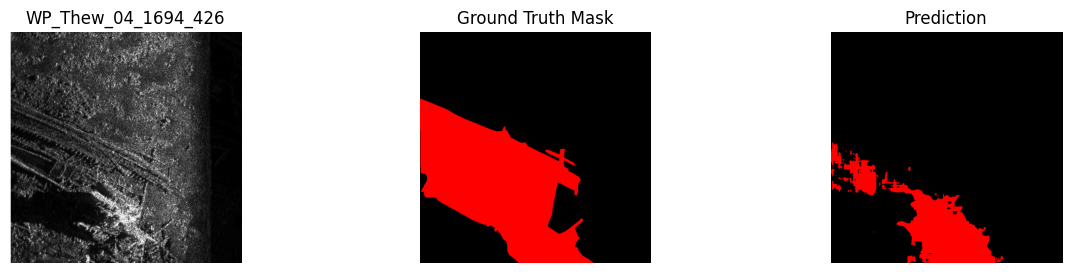

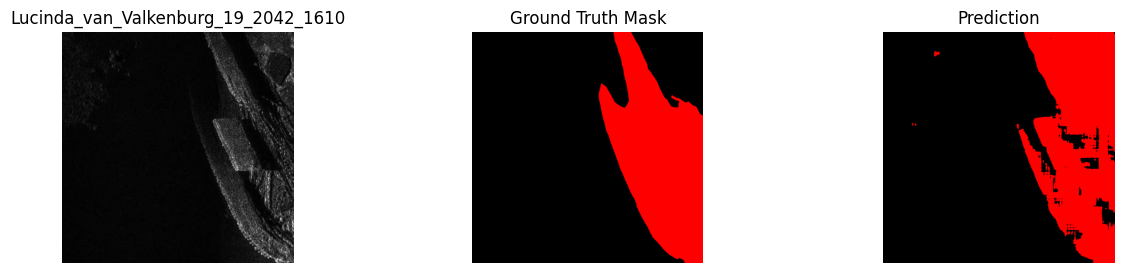

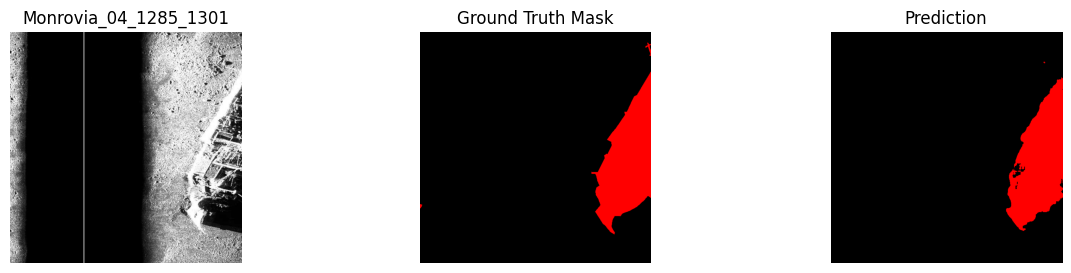

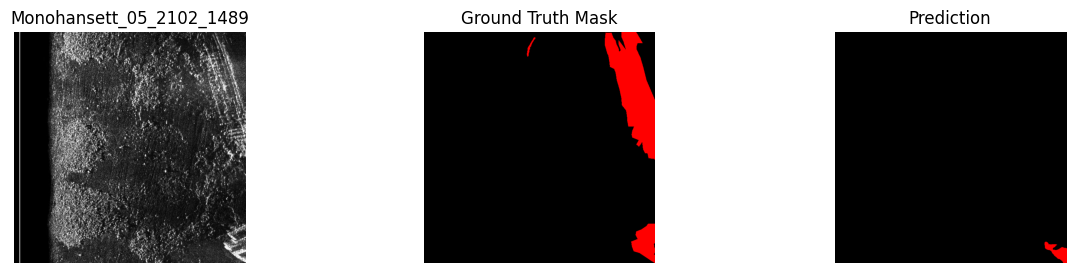

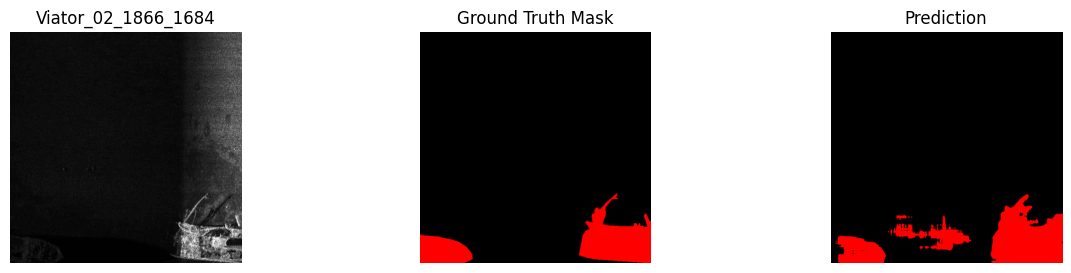

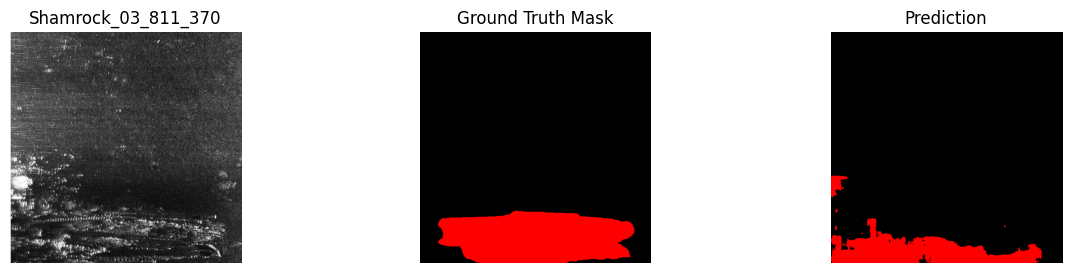

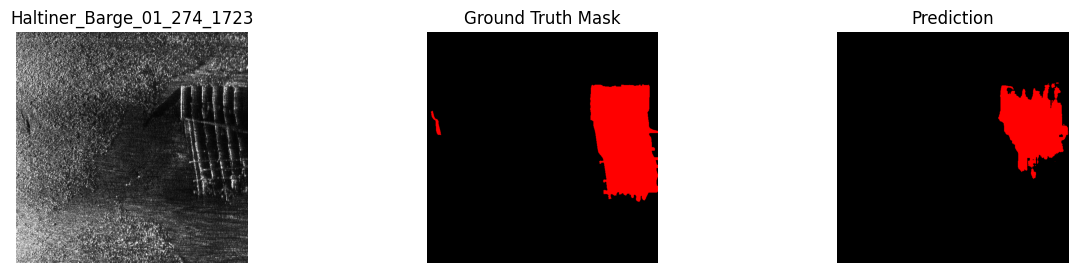

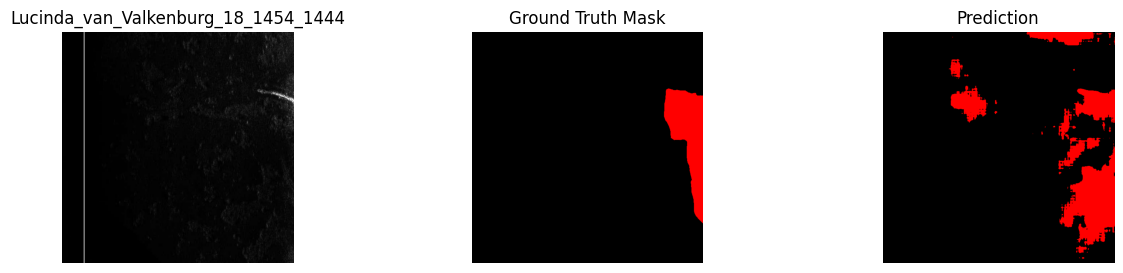

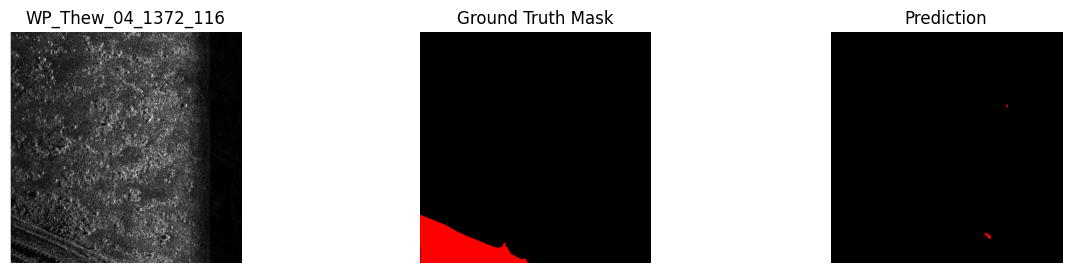

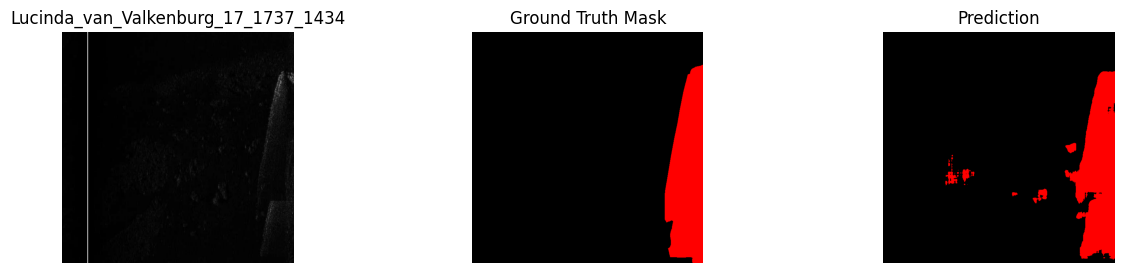

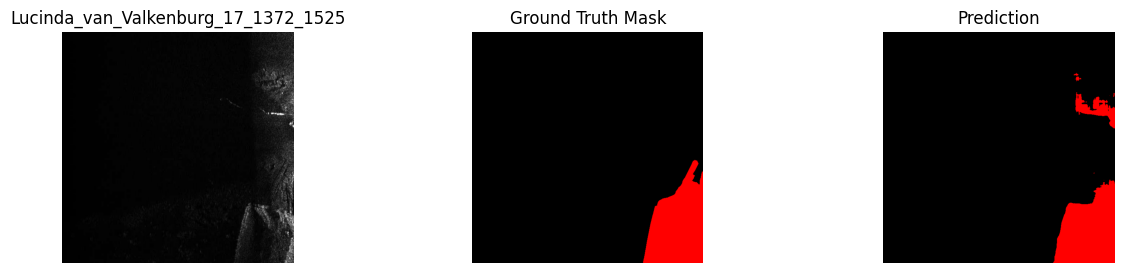

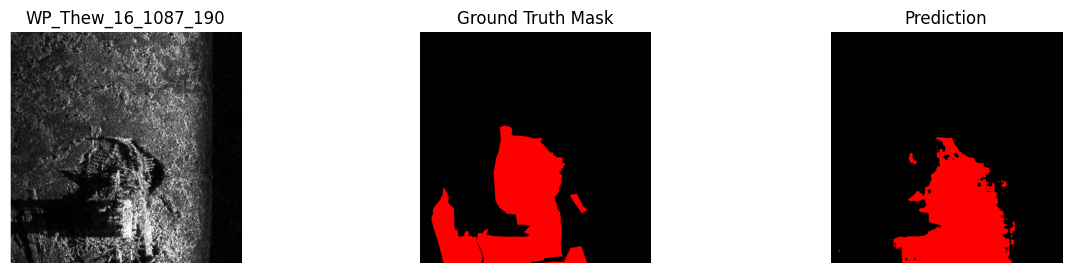

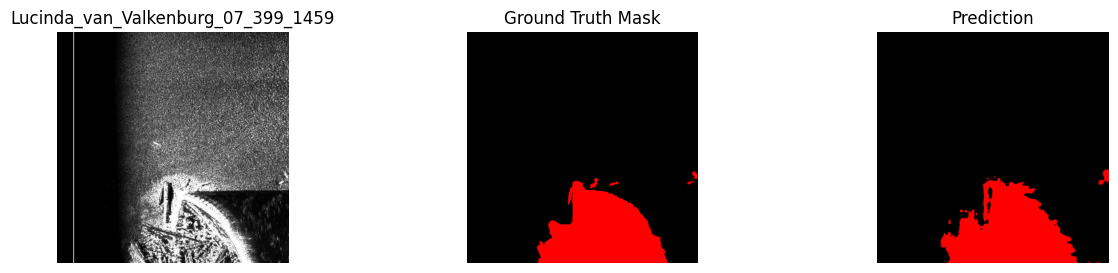

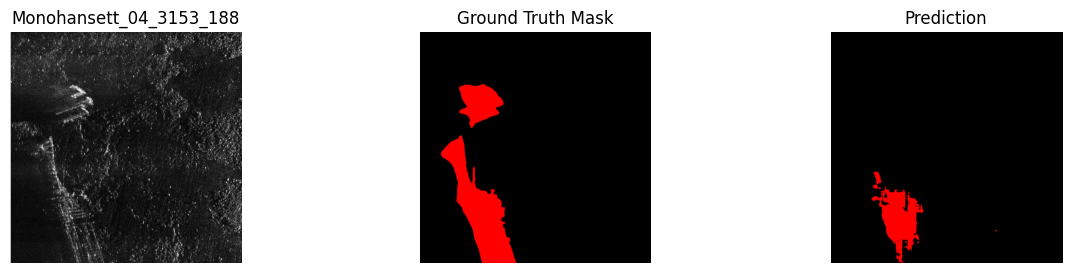

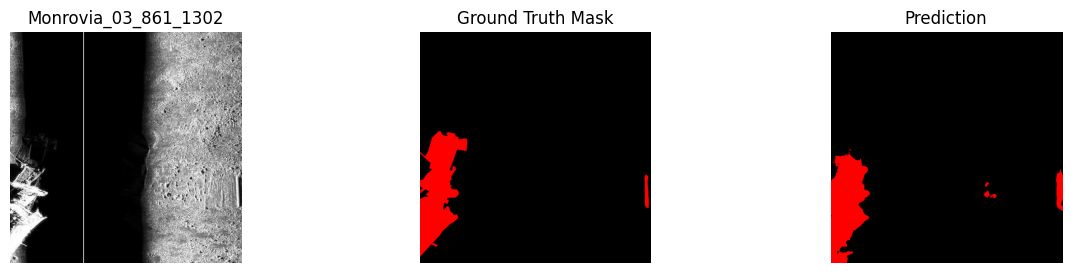

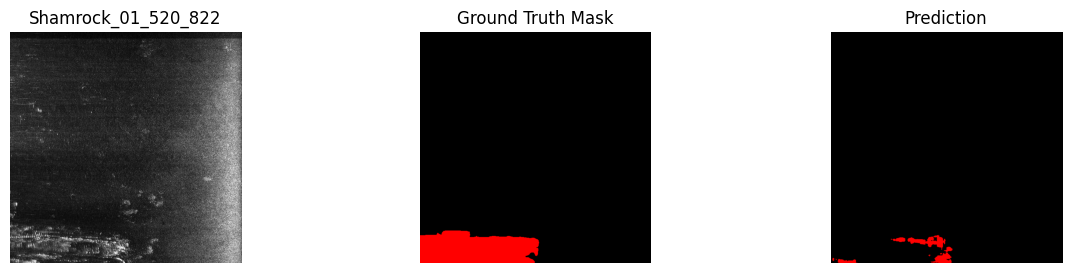

In [13]:
loaded_model = UNetShipwreckDecoder().to(DEVICE)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

colors = (np.array((0, 0, 0)), np.array((1, 0, 0)))

for file in random.choices(TEST_FILES, k=100):
    mask = cv2.imread(str(MASK_PATH / (file + DATA_EXT)), cv2.IMREAD_UNCHANGED).astype(np.float32)
    if (np.sum(mask == 1.0) / np.sum(mask >= 0.0)) < 0.05:
        continue

    img = cv2.imread(str(IMGS_PATH / (file + DATA_EXT)), cv2.IMREAD_COLOR_RGB)
    with np.load(EMBEDS_PATH / (file + '.npz')) as data:
        s1 = torch.from_numpy(data['stage3'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s2 = torch.from_numpy(data['stage2'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s3 = torch.from_numpy(data['stage1'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
        s4 = torch.from_numpy(data['stage0'].astype(np.float32)).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    logits = loaded_model(s1, s2, s3, s4)
    probs = torch.sigmoid(logits)
    pred = (probs > 0.10).int().squeeze(0).squeeze(0).cpu().numpy()

    mask_rgb = np.zeros((mask.shape[0], mask.shape[1], 3))
    pred_rgb = np.zeros((mask.shape[0], mask.shape[0], 3))

    for label, color in zip((0.0, 1.0), colors):
        mask_rgb[mask == label] = color[:3]
        pred_rgb[pred == label] = color[:3]

    show_images(
        [(img, file), (mask_rgb, "Ground Truth Mask"), (pred_rgb, "Prediction")],
        num_images=3,
        normalize=False,
        cmap=None
    )